# 04 · Baselines and Honest Evaluation

"Our model achieves an MAE of 48" means nothing on its own. Is 48 good? Compared with what? This chapter builds the machinery that answers that question for the rest of the course:

1. **Baselines**: simple forecasts that take one line of code. Any real model has to beat them, or it isn't worth its complexity.
2. **Metrics** that measure the right thing and can be compared across horizons and series.
3. **A backtest** that imitates real forecasting: the model only ever sees the past.

Nothing here is glamorous, but it's what separates forecasting from wishful thinking. A surprising number of published models fail to beat the baselines in this chapter.

**By the end of this chapter you will be able to**

- implement the standard baseline forecasts, including naive, seasonal naive, drift and climatology
- choose between MAE, RMSE and MASE, and explain why MAPE misleads on data like ours
- explain which point forecast each metric rewards
- run a **rolling-origin backtest** and read error as a function of horizon
- recognise **leakage** and build honest **prediction intervals** from past errors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import tsutils

tsutils.set_style()
pd.set_option("display.precision", 1)

---
## 1. The forecasting task for the rest of the course

From here on, every model answers the same question:

> **Given daily mean PM2.5 up to and including today, forecast each of the next 7 days.**

Daily means are what air-quality warnings are based on, and chapter 03 showed they are mean-reverting with a half-life of about a day. The horizons span "tomorrow", where recent data should help a lot, to "next week", where it probably won't.

We split the six years into three roles:

| Period | Role |
|---|---|
| 2010–2013 | **history**: always available for fitting |
| 2014 | **development**: backtests for comparing and tuning models, in chapters 04–10 |
| 2015 | **locked test year**: touched **once**, in the capstone (chapter 11) |

Why lock a whole year away? Every time you look at test results and change something, the test set leaks a little into your decisions. After enough rounds, a good test score says more about your persistence than about your model. Keeping 2015 untouched means the capstone gives an honest estimate of how the final models would do on genuinely new data. And 2015 is the year the level dropped (chapter 03), so it's a realistic stress test.

In [2]:
daily = tsutils.load_daily_pm25()
y = daily["pm25"]            # gap-free: what models learn from
actual = daily["actual"]     # NaN on days with < 18 hourly readings: never scored

print(f"{len(y):,} days, {actual.isna().sum()} too thin to score "
      f"({actual['2014'].isna().sum()} of them in 2014)")
daily.head()

2,191 days, 91 too thin to score (2 of them in 2014)


,pm25,actual
timestamp,,
2010-01-01,144.3,NaN
2010-01-02,144.3,144.3
2010-01-03,78.4,78.4
2010-01-04,29.3,29.3
2010-01-05,43.5,43.5


`tsutils.load_daily_pm25()` repeats chapter 01's recipe: interpolate short hourly gaps, average to days, and flag days with fewer than 18 readings. Those thin days are interpolated so models get an unbroken history, but their `actual` is `NaN`, so **no forecast is ever scored against an interpolated value**.

---
## 2. Six baselines

A forecaster here is any function that takes the history up to today and returns the next `horizon` values. Each baseline encodes one simple belief about the future.

In [3]:
def mean_forecast(history, horizon):
    """The future looks like the long-run average."""
    return np.full(horizon, history.mean())

def naive_forecast(history, horizon):
    """The future looks like today."""
    return np.full(horizon, history.iloc[-1])

def seasonal_naive_forecast(history, horizon, period=7):
    """The future repeats the last cycle (here: same weekday last week)."""
    last_cycle = history.iloc[-period:].to_numpy()
    return np.tile(last_cycle, int(np.ceil(horizon / period)))[:horizon]

def drift_forecast(history, horizon):
    """Continue the straight line from the first observation to the last."""
    slope = (history.iloc[-1] - history.iloc[0]) / (len(history) - 1)
    return history.iloc[-1] + slope * np.arange(1, horizon + 1)

def moving_average_forecast(history, horizon, window=7):
    """The future looks like the recent average."""
    return np.full(horizon, history.iloc[-window:].mean())

def climatology_forecast(history, horizon, window=15, stat="median"):
    """The future looks like a typical day at this time of year.

    For each target date, summarise every past value within `window` days
    of the same day of the year (wrapping around New Year).
    """
    targets = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    doy = history.index.dayofyear.to_numpy()
    values = history.to_numpy()
    summarise = np.median if stat == "median" else np.mean
    out = []
    for target_doy in targets.dayofyear:
        distance = np.abs(doy - target_doy)
        distance = np.minimum(distance, 365 - distance)
        out.append(summarise(values[distance <= window]))
    return np.array(out)

Let's see all six from a single forecast origin: 20 February 2014, in the middle of a bad winter episode.

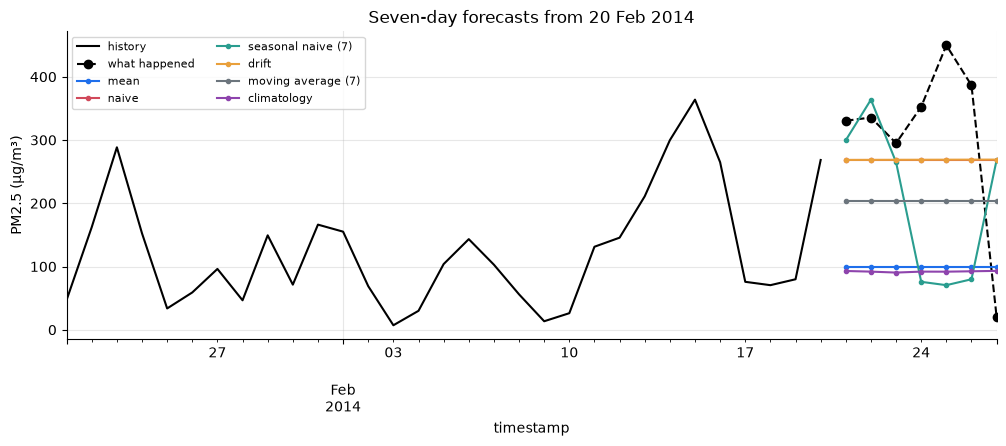

In [4]:
baselines = {
    "mean": mean_forecast,
    "naive": naive_forecast,
    "seasonal naive (7)": seasonal_naive_forecast,
    "drift": drift_forecast,
    "moving average (7)": moving_average_forecast,
    "climatology": climatology_forecast,
}

origin = pd.Timestamp("2014-02-20")
history = y[:origin]
future = actual[origin + pd.Timedelta(days=1): origin + pd.Timedelta(days=7)]

ax = y[origin - pd.Timedelta(days=30): origin].plot(color="k", label="history")
future.plot(ax=ax, color="k", ls="--", marker="o", label="what happened")
for name, forecaster in baselines.items():
    pd.Series(forecaster(history, 7), index=future.index).plot(ax=ax, marker=".", label=name)
ax.set(title=f"Seven-day forecasts from {origin:%d %b %Y}", ylabel="PM2.5 (µg/m³)")
ax.legend(ncol=2, fontsize=8);

One origin tells us almost nothing. Any method can get lucky or unlucky on one week. We need to repeat this for **hundreds of origins** and average. First, though, we need to decide *how* to score a forecast.

---
## 3. Metrics

For forecasts $\hat y_t$ of actuals $y_t$, with errors $e_t = \hat y_t - y_t$:

| Metric | Formula | Units | Notes |
|---|---|---|---|
| **MAE** | $\frac{1}{n}\sum \lvert e_t\rvert$ | µg/m³ | easy to explain: "typically off by X" |
| **RMSE** | $\sqrt{\frac{1}{n}\sum e_t^2}$ | µg/m³ | punishes large misses much more |
| **Bias** | $\frac{1}{n}\sum e_t$ | µg/m³ | systematic over- (+) or under- (−) forecasting |
| **MASE** | $\text{MAE} \,/\, \text{MAE of in-sample one-step naive}$ | none | < 1 beats one-step naive on the training data |
| MAPE | $\frac{100}{n}\sum \lvert e_t / y_t\rvert$ | % | popular, but see below |

**MASE** (Hyndman & Koehler, 2006) is the one to use when comparing across series with different scales, because it divides out the units. Its denominator is a *one-step* naive error, so multi-step forecasts will usually score above 1. That's expected. It isn't failure.

### Why not MAPE?

MAPE divides by the actual value, so days with **very little pollution** carry enormous weight. A forecast of 30 µg/m³ on a day that turns out to be 3 µg/m³ is a 900% error, while missing a 400 µg/m³ smog day by 200 is only 50%. For public health, the second miss is far worse. We'll check this on real forecasts in section 5.

### Each metric rewards a different forecast

This is subtle but important:

- **MAE** is minimised by forecasting the **median** of what might happen.
- **RMSE** is minimised by forecasting the **mean**.

PM2.5 is right-skewed, with occasional huge episodes, so its mean sits well above its median. The best forecast therefore *depends on the metric you'll be judged by*. Decide the metric first, then build the forecast for it. We'll see this with two versions of climatology, one using the median and one using the mean.

---
## 4. The rolling-origin backtest

A single train/test split gives one noisy number. Instead we **roll the forecast origin** forward one day at a time through 2014. At each origin the forecaster sees only the data up to that day, forecasts the next 7 days, and we record every forecast next to what actually happened.

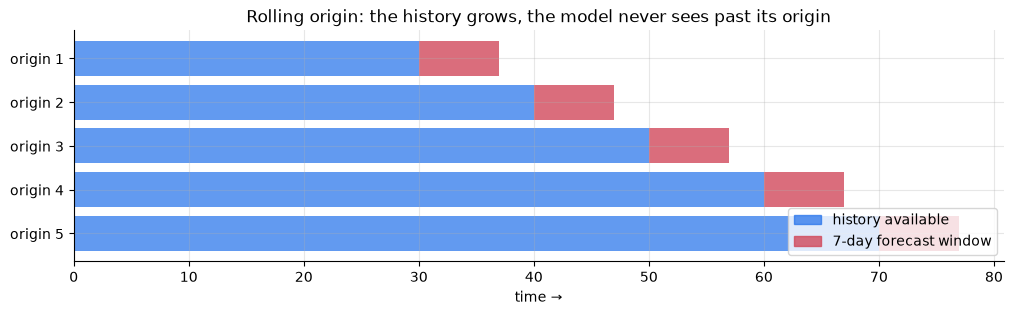

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
for row, start in enumerate(range(0, 50, 10)):
    ax.barh(row, 30 + start, left=0, color="#1f6feb", alpha=0.7)
    ax.barh(row, 7, left=30 + start, color="#d1495b", alpha=0.8)
ax.set(yticks=range(5), yticklabels=[f"origin {i + 1}" for i in range(5)],
       xlabel="time →", title="Rolling origin: the history grows, the model never sees past its origin")
ax.invert_yaxis()
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#1f6feb", alpha=0.7),
                   plt.Rectangle((0, 0), 1, 1, color="#d1495b", alpha=0.8)],
          labels=["history available", "7-day forecast window"], loc="lower right");

In [6]:
def backtest(y, forecaster, origins, horizon, actuals=None):
    """For each origin, forecast `horizon` steps from the history up to that origin."""
    actuals = y if actuals is None else actuals
    rows = []
    for origin in origins:
        pos = y.index.get_loc(origin)
        forecast = np.asarray(forecaster(y.iloc[: pos + 1], horizon), dtype=float)
        dates = y.index[pos + 1 : pos + 1 + horizon]
        rows.append(pd.DataFrame({
            "origin": origin,
            "h": np.arange(1, len(dates) + 1),
            "date": dates,
            "forecast": forecast[: len(dates)],
            "actual": actuals.reindex(dates).to_numpy(),
        }))
    return pd.concat(rows, ignore_index=True)

origins = tsutils.BACKTEST_ORIGINS
print(f"{len(origins)} origins, {origins[0]:%d %b %Y} → {origins[-1]:%d %b %Y}; horizon {tsutils.HORIZON} days")

bt_naive = backtest(y, naive_forecast, origins, tsutils.HORIZON, actuals=actual)
bt_naive.head(9)

359 origins, 31 Dec 2013 → 24 Dec 2014; horizon 7 days


,origin,h,date,forecast,actual
0,2013-12-31,1,2014-01-01,49.3,58.4
1,2013-12-31,2,2014-01-02,49.3,167.6
2,2013-12-31,3,2014-01-03,49.3,54.5
3,2013-12-31,4,2014-01-04,49.3,154.9
4,2013-12-31,5,2014-01-05,49.3,101.4
5,2013-12-31,6,2014-01-06,49.3,154.6
6,2013-12-31,7,2014-01-07,49.3,112.9
7,2014-01-01,1,2014-01-02,58.4,167.6
8,2014-01-01,2,2014-01-03,58.4,54.5


The first origin is 31 December 2013, so every target date falls inside 2014, and the last origin is chosen so its 7-day window ends on 31 December. The same function lives in `tsutils.backtest`, and the standard origins in `tsutils.BACKTEST_ORIGINS`. Let's confirm the notebook version and the library version agree:

In [7]:
pd.testing.assert_frame_equal(
    bt_naive,
    tsutils.backtest(y, tsutils.naive_forecast, origins, tsutils.HORIZON, actuals=actual))
print("identical")

identical


---
## 5. Results: which baseline wins, and when?

Now we run every baseline through the same backtest. We add the mean-based climatology from section 3, and score everything with `tsutils.evaluate`, which gives MAE, RMSE and bias per step ahead and skips unscorable days.

In [8]:
all_baselines = baselines | {
    "climatology (mean)": lambda h, H: climatology_forecast(h, H, stat="mean"),
}
all_baselines["climatology (median)"] = all_baselines.pop("climatology")

backtests = {name: backtest(y, f, origins, tsutils.HORIZON, actuals=actual)
             for name, f in all_baselines.items()}
scores = {name: tsutils.evaluate(bt) for name, bt in backtests.items()}

mae_by_h = pd.DataFrame({name: s["MAE"] for name, s in scores.items()})
mae_by_h

,mean,naive,seasonal naive (7),drift,moving average (7),climatology (mean),climatology (median)
h,,,,,,,
1,58.9,51.1,76.8,51.1,59.0,57.2,56.1
2,59.1,72.2,76.7,72.3,63.6,57.5,56.6
3,59.3,81.3,77.0,81.3,64.6,57.8,56.8
4,59.4,81.6,77.4,81.7,64.4,57.9,57.1
5,59.4,76.3,77.2,76.4,64.3,57.9,57.1
6,59.6,75.1,77.2,75.2,64.7,58.1,57.1
7,59.7,76.9,76.9,77.1,64.5,58.2,57.1


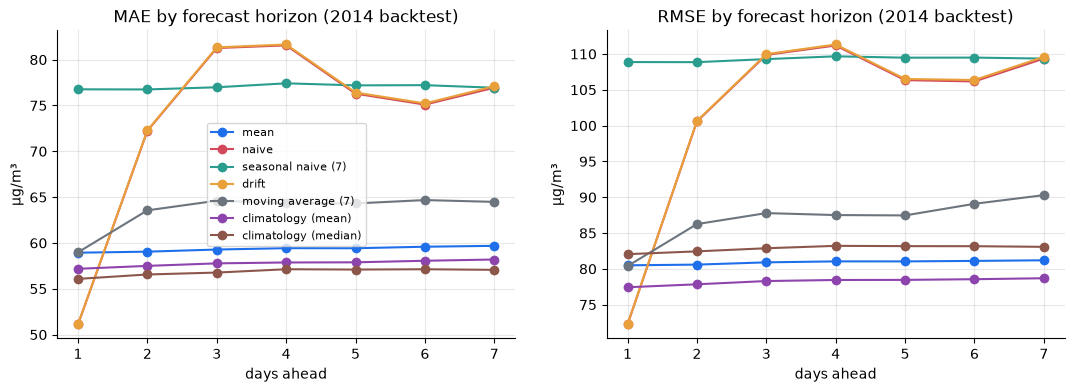

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for metric, ax in zip(["MAE", "RMSE"], axes):
    for name, s in scores.items():
        ax.plot(s.index, s[metric], marker="o", label=name)
    ax.set(title=f"{metric} by forecast horizon (2014 backtest)", xlabel="days ahead", ylabel="µg/m³")
axes[0].legend(fontsize=8);

This is the most important figure in the chapter. Things to notice:

- **Naive wins for tomorrow, then collapses.** "Tomorrow looks like today" is the best of these forecasts one day ahead. From day 2 it's among the worst, because it confidently repeats a smog peak that has usually cleared by then. That's the one-day half-life from chapter 03, seen from the forecaster's side.
- **Climatology wins from day 2 onwards.** Once today's information has faded, the best guess is "a typical day for this time of year". Its error is almost flat across horizons, because it ignores the most recent data entirely.
- **Seasonal naive (7) and drift are poor.** PM2.5 has no weekly cycle (chapter 01) and no straight-line trend, so baselines that assume them do badly. Drift sits almost exactly on top of naive: over four years of history, the start-to-end slope is close to zero. A baseline is only strong if its assumption matches the data.
- **The metric picks the winner.** On MAE the *median* climatology beats the mean version. On RMSE the ranking flips, just as section 3 predicted.

So the targets for every later model are **beat naive at 1 day, beat climatology beyond that**. A model that manages both has learned how quickly today's conditions fade, which is exactly what the ARMA models in chapter 06 are designed to do.

In [10]:
train = y[: origins[0]]
mase_scale = np.mean(np.abs(np.diff(train.to_numpy())))    # in-sample one-step naive MAE

summary = pd.DataFrame({
    "MAE (all h)": {n: s["MAE"].mean() for n, s in scores.items()},
    "RMSE (all h)": {n: np.sqrt((s["RMSE"] ** 2).mean()) for n, s in scores.items()},
    "MASE": {n: s["MAE"].mean() / mase_scale for n, s in scores.items()},
    "bias": {n: s["bias"].mean() for n, s in scores.items()},
})
summary["skill vs naive"] = 1 - summary["MAE (all h)"] / summary.loc["naive", "MAE (all h)"]
summary.sort_values("MAE (all h)").style.format(
    {"MAE (all h)": "{:.1f}", "RMSE (all h)": "{:.1f}", "MASE": "{:.2f}", "bias": "{:+.1f}", "skill vs naive": "{:+.0%}"})

,MAE (all h),RMSE (all h),MASE,bias,skill vs naive
climatology (median),56.8,82.9,1.14,-17.5,+23%
climatology (mean),57.8,78.2,1.16,+1.7,+21%
mean,59.3,80.9,1.19,+2.4,+19%
moving average (7),63.6,87.0,1.28,-0.2,+14%
naive,73.5,103.0,1.48,-0.3,+0%
drift,73.6,103.2,1.48,-0.4,-0%
seasonal naive (7),77.0,109.3,1.55,-0.0,-5%


Two more things are worth reading from this table:

- **Every MASE is above 1.** A one-step naive forecast *within* the training data is a tough yardstick for 7-day-ahead forecasts. This will be true of every model in the course, and it's fine.
- **The median climatology has a negative bias.** It forecasts *below* the actual value on average, and that's exactly what it should do. The median of a right-skewed distribution sits below its mean. A negative bias is the price of minimising MAE, not a bug.

### MAPE on the same forecasts

In [11]:
naive_rows = backtests["naive"].dropna(subset=["actual"])
ape = 100 * (naive_rows["forecast"] - naive_rows["actual"]).abs() / naive_rows["actual"]
clean_days = naive_rows["actual"] < 20

print(f"naive MAPE: {ape.mean():.0f}%   (median APE {ape.median():.0f}%, worst {ape.max():,.0f}%)")
print(f"days with actual < 20 µg/m³: {clean_days.mean():.0%} of forecasts, "
      f"but {ape[clean_days].sum() / ape.sum():.0%} of total MAPE")

naive MAPE: 149%   (median APE 64%, worst 5,466%)
days with actual < 20 µg/m³: 7% of forecasts, but 36% of total MAPE


A small share of clean-air days dominates the metric. Optimising MAPE would push a model towards forecasting *low* values, at the expense of the smog days that matter. We'll use MAE as the headline metric and report RMSE alongside, because large misses are what hurt.

### Saving the scoreboard

Every later chapter adds its models to one results file, which the capstone reads to build the final leaderboard.

In [12]:
for name, s in scores.items():
    tsutils.save_scores(name, s)

tsutils.load_scores().pivot(index="h", columns="model", values="MAE").round(1)

model,climatology (mean),climatology (median),drift,mean,moving average (7),naive,seasonal naive (7)
h,,,,,,,
1,57.2,56.1,51.1,58.9,59.0,51.1,76.8
2,57.5,56.6,72.3,59.1,63.6,72.2,76.7
3,57.8,56.8,81.3,59.3,64.6,81.3,77.0
4,57.9,57.1,81.7,59.4,64.4,81.6,77.4
5,57.9,57.1,76.4,59.4,64.3,76.3,77.2
6,58.1,57.1,75.2,59.6,64.7,75.1,77.2
7,58.2,57.1,77.1,59.7,64.5,76.9,76.9


---
## 6. Leakage: when the backtest peeks at the future

**Leakage** is any path by which information from after the forecast origin reaches the forecast. Our `backtest` prevents the obvious path by only passing `y` up to the origin. Leaks can still come in through anything computed *outside* the forecaster.

Here is a realistic one. Suppose you computed "typical PM2.5 for each day of the year" **once**, from all of 2010–2014, and then used that table inside the backtest. It looks harmless: it's just a seasonal profile. But when forecasting a day in 2014, the table already contains that very day.

In [13]:
leaky_source = y[:"2014"]            # includes the year we're evaluating on!

def leaky_climatology(history, horizon, window=15):
    """Same recipe as climatology_forecast, but the profile comes from leaky_source."""
    targets = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    doy, values = leaky_source.index.dayofyear.to_numpy(), leaky_source.to_numpy()
    out = []
    for target_doy in targets.dayofyear:
        distance = np.abs(doy - target_doy)
        distance = np.minimum(distance, 365 - distance)
        out.append(np.median(values[distance <= window]))
    return np.array(out)

leaky = tsutils.evaluate(backtest(y, leaky_climatology, origins, tsutils.HORIZON, actuals=actual))
honest = scores["climatology (median)"]
print(f"honest climatology MAE: {honest['MAE'].mean():.1f}")
print(f"leaky  climatology MAE: {leaky['MAE'].mean():.1f}")

honest climatology MAE: 56.8
leaky  climatology MAE: 55.9


The leak makes climatology look almost 2% better. That sounds small, but it's about as large as the gap between the median and mean climatologies above, which was enough to decide a winner. Leaks rarely announce themselves with spectacular scores. More often they quietly hand an advantage to whichever model happens to contain one, and flip conclusions you thought were solid.

Common sources to watch for in later chapters:

- **Preprocessing on the full series**: interpolation, scaling, or smoothing computed before the split (chapter 01's caveat).
- **Features that use the future**: centred rolling windows, "daily totals" that include later hours.
- **Tuning on the evaluation period**: choosing a setting because it scored best on 2014, then reporting its 2014 score (Exercise 4).
- **Random train/test splits**: shuffling rows lets a model train on Thursday and be "tested" on the Wednesday before it (chapter 09).

---
## 7. Honest uncertainty: prediction intervals from past errors

A point forecast hides how uncertain we are. A simple, assumption-light way to build an interval is to **use the model's own past errors**:

1. Run the backtest on an **earlier** period (2013) and collect the errors at each horizon.
2. Take their 10th and 90th percentiles. Adding those to a new forecast gives an **80% interval**.
3. **Check** it on a later period (2014): about 80% of actuals should land inside.

PM2.5 errors scale with the level, since a bad day can miss by hundreds, so we work with **log ratios** $\log(y / \hat y)$. That makes the interval multiplicative, and it can never dip below zero.

In [14]:
calibration_origins = pd.date_range("2012-12-31", "2013-12-24", freq="D")

def interval_factors(forecaster, lower=0.10, upper=0.90):
    """Per-horizon multiplicative interval factors, learned from 2013 errors."""
    cal = backtest(y, forecaster, calibration_origins, tsutils.HORIZON, actuals=actual).dropna(subset=["actual"])
    log_ratio = np.log(cal["actual"] / cal["forecast"])
    return log_ratio.groupby(cal["h"]).quantile([lower, upper]).unstack().pipe(np.exp)

coverage = {}
for name in ["naive", "climatology (median)"]:
    factors = interval_factors(all_baselines[name])
    rows = backtests[name].dropna(subset=["actual"]).join(factors, on="h")
    inside = (rows["actual"] >= rows["forecast"] * rows[0.10]) & (rows["actual"] <= rows["forecast"] * rows[0.90])
    coverage[name] = inside.groupby(rows["h"]).mean()

pd.DataFrame(coverage).style.format("{:.0%}")

,naive,climatology (median)
h,,
1,77%,81%
2,80%,80%
3,75%,80%
4,74%,79%
5,78%,80%
6,78%,80%
7,76%,80%


Climatology's intervals hit the 80% target almost exactly at every horizon, even though they were learned only from 2013. Naive's run a little short, at 74–80%: its errors depend on how much PM2.5 changes from day to day, and 2014's swings were somewhat larger than 2013's. Intervals calibrated on one period inherit that period's volatility, which is why checking coverage on *different* data matters. Let's draw them for one stretch of 2014:

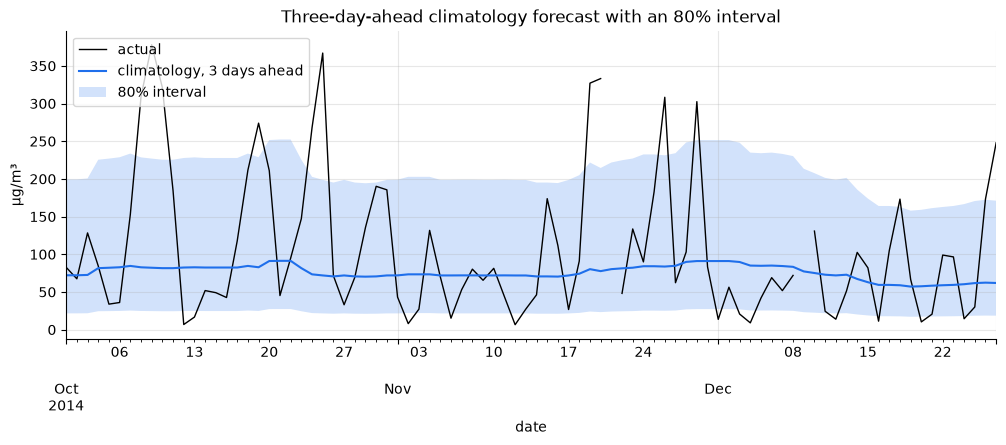

In [15]:
factors = interval_factors(climatology_forecast)
one_day = backtests["climatology (median)"].query("h == 3").set_index("date").loc["2014-10":"2014-12"]
lo, hi = one_day["forecast"] * factors.loc[3, 0.10], one_day["forecast"] * factors.loc[3, 0.90]

ax = one_day["actual"].plot(color="k", lw=1, label="actual")
one_day["forecast"].plot(ax=ax, label="climatology, 3 days ahead")
ax.fill_between(one_day.index, lo, hi, alpha=0.2, label="80% interval")
ax.set(title="Three-day-ahead climatology forecast with an 80% interval", ylabel="µg/m³")
ax.legend(loc="upper left");

The interval is **wide**, often spanning 20 to 250 µg/m³, and that's honest. It says that climatology knows the season, but not whether next Tuesday will be clear or smoggy. A better model should earn a **narrower** interval with the same 80% coverage. That's as important a target as a lower MAE.

---
## Exercises

### Exercise 1: A series where seasonal naive shines
Load the monthly Mauna Loa CO₂ series (as in chapter 03). Backtest `naive`, a 12-month **seasonal naive**, and `drift` with monthly origins from January 1990 to December 2000 and a 12-month horizon, using `tsutils.backtest` and `tsutils.evaluate`. Then build a **seasonal naive with drift**: repeat last year's values, plus one year's growth for each year ahead, where the growth is the mean of the last 12 months minus the mean of the 12 before. Which baseline wins at 1, 6 and 12 months ahead?

<details><summary>Solution</summary>

```python
co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
co2_origins = pd.date_range("1990-01-01", "2000-12-01", freq="MS")

def seasonal_naive_drift(history, horizon, period=12):
    growth = history.iloc[-period:].mean() - history.iloc[-2 * period:-period].mean()
    years_ahead = np.ceil(np.arange(1, horizon + 1) / period)
    return seasonal_naive_forecast(history, horizon, period) + growth * years_ahead

co2_models = {
    "naive": naive_forecast,
    "seasonal naive (12)": lambda h, H: seasonal_naive_forecast(h, H, period=12),
    "drift": drift_forecast,
    "seasonal naive + drift": seasonal_naive_drift,
}
pd.DataFrame({name: tsutils.evaluate(tsutils.backtest(co2, f, co2_origins, 12))["MAE"]
              for name, f in co2_models.items()}).loc[[1, 6, 12]]
```
Plain naive and drift suffer badly at 6 months, where they ignore half a seasonal wave. Seasonal naive is steady but always a year's growth behind. Seasonal naive + drift wins at 1 and 6 months. **At exactly 12 months, though, plain drift catches up and even wins.** A 12-month-ahead target falls in the same calendar month as the origin, so ignoring seasonality costs nothing there, and drift's long-run slope is a steadier growth estimate than one year's change. That's a good reason to always read errors **by horizon**, since an average over horizons would hide it. For CO₂, a model has to beat a **seasonal** baseline, which is a much higher bar than for PM2.5. The right baseline depends on the structure you found in chapters 02–03.
</details>

### Exercise 2: Damped persistence
Chapter 03 estimated a lag-1 autocorrelation of $\phi \approx 0.53$ for daily PM2.5. Build a forecast that starts at today's value and **decays towards climatology** at that rate:

$$\hat y_{t+h} = c_{t+h} + \phi^h\,(y_t - c_{t+h}),$$

where $c$ is the mean climatology. Backtest it. Does it beat naive at $h = 1$? Does it beat climatology later?

<details><summary>Solution</summary>

```python
phi = 0.53

def damped_persistence(history, horizon):
    clim = climatology_forecast(history, horizon, stat="mean")
    return clim + phi ** np.arange(1, horizon + 1) * (history.iloc[-1] - clim)

damped = tsutils.evaluate(backtest(y, damped_persistence, origins, 7, actuals=actual))
pd.DataFrame({"damped": damped["MAE"], "naive": scores["naive"]["MAE"],
              "climatology (median)": scores["climatology (median)"]["MAE"]})
```
It clearly beats naive at one day ahead and is close to climatology beyond that. It starts where naive is strong and ends where climatology is strong. It trails the *median* climatology slightly at long horizons because it decays towards the *mean*, which MAE doesn't reward. Two numbers, $\phi$ and a seasonal profile, capture most of what's forecastable here. This is essentially an AR(1) model around a seasonal mean, which chapter 06 fits properly.
</details>

### Exercise 3: Combining forecasts
Average the naive and median-climatology forecasts, 50/50. Backtest the combination. Where does it beat both of its ingredients, and where does it lose? How does it compare with Exercise 2?

<details><summary>Solution</summary>

```python
def naive_climatology_combo(history, horizon):
    return 0.5 * naive_forecast(history, horizon) + 0.5 * climatology_forecast(history, horizon)

combo = tsutils.evaluate(backtest(y, naive_climatology_combo, origins, 7, actuals=actual))
pd.DataFrame({"combo": combo["MAE"], "naive": scores["naive"]["MAE"],
              "climatology (median)": scores["climatology (median)"]["MAE"]})
```
At one day ahead the combination beats both ingredients. Averaging forecasts whose errors are only partly correlated often does, which is one of the most dependable results in forecasting. At longer horizons it's dragged down by the naive half, which no longer carries information. A fixed 50/50 weight is too crude: the weight on "today" should **shrink with the horizon**, and that's exactly what Exercise 2's $\phi^h$ does.
</details>

### Exercise 4: Tune on one year, report on the next
Climatology has a setting: the `window` (in days) around each date of the year. Try `window` values of 3, 7, 15, 30, 45, 60 and 90.
1. Choose the best window using a backtest on **2013** (`calibration_origins`), then report that window's 2014 MAE.
2. Compare with the window that *would* have been best if you'd chosen it by looking at 2014 directly.

<details><summary>Solution</summary>

```python
windows = [3, 7, 15, 30, 45, 60, 90]
tuning = pd.DataFrame({
    period: {w: tsutils.evaluate(backtest(y, lambda h, H, w=w: climatology_forecast(h, H, window=w),
                                          period_origins, 7, actuals=actual))["MAE"].mean()
             for w in windows}
    for period, period_origins in [("2013 (tuning)", calibration_origins), ("2014 (reporting)", origins)]
})
chosen = tuning["2013 (tuning)"].idxmin()
print(f"chosen on 2013: window={chosen} -> 2014 MAE {tuning.loc[chosen, '2014 (reporting)']:.2f}")
print(f"best in hindsight on 2014: window={tuning['2014 (reporting)'].idxmin()} "
      f"-> {tuning['2014 (reporting)'].min():.2f}")
tuning
```
The window chosen on 2013 does almost as well in 2014 as the best-in-hindsight choice. Here the gap, the optimism you'd have reported by tuning on the test data, is tiny, because this setting barely matters. With flexible models and dozens of settings the gap grows quickly, and this two-period discipline is what keeps it honest. It's also why 2015 stays locked.
</details>

---
## Key takeaways

- A model's score only means something **next to a baseline**. Naive, seasonal naive, drift and climatology each encode one belief about the future.
- The **rolling-origin backtest** is the standard evaluation: many origins, the model sees only the past, and error is read **by horizon**.
- **MAE** rewards forecasting the median, **RMSE** the mean. Pick the metric first. **MAPE** is dominated by small actuals, so avoid it for data like PM2.5. **MASE** makes errors comparable across series.
- For daily PM2.5: **naive wins at 1 day, climatology from 2 days**. Every later model has to beat both, and the scoreboard is saved in `results/`.
- **Leakage** is usually subtle. Compute everything from data available at the origin, and **tune on a different period from the one you report**.
- Intervals built from past errors are simple and honest, but **check their coverage** on data they weren't calibrated on.

**Next:** *05 · Exponential Smoothing*. Our first real forecasting models: weighted averages that let recent days count more, with weights learned from the data.